# NYC-Temperature -- does the weather on Wall Street move the tape?
### The trader-mood / sunshine effect, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

Here is a tidy piece of behavioural-finance folklore: traders are human, human moods track the weather, and the New York Stock Exchange sits in New York City -- so the **temperature on Wall Street** should nudge the day's returns. Cold, grey days make people gloomy and risk-averse (sell); mild, sunny days make them cheerful (buy). It *sounds* plausible, and a famous paper ('Good Day Sunshine') even found a sunshine effect across 26 cities. This notebook asks the only question that matters: when we line up six decades of NYC daily temperature against the S&P 500, is there anything there -- or is it weather astrology?

> **This is the plain-language layer.** Want the Newey-West HAC t-stat, the permutation distribution, and the net-of-cost backtest? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from nyc_temperature import data, strategy as st

def _load_real():
    try:
        return data.fetch_gspc_daily(fetch=False)
    except FileNotFoundError:
        return None

REAL = _load_real()
HAVE_REAL = REAL is not None
print("^GSPC daily cache present:", HAVE_REAL)

# Offline fallback: a synthetic NULL tape standing in for the real daily span.
if HAVE_REAL:
    TAPE = REAL
    TAPE_LABEL = "REAL ^GSPC daily (cache)"
else:
    TAPE, _ = data.synthetic_daily(n_days=16000, premium_bps=0.0, seed=282)
    TAPE_LABEL = "SYNTHETIC null tape (no real cache) -- NOT a real-tape result"
print("Tape:", TAPE_LABEL, "| rows:", len(TAPE))

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-15)
R = dict(
    n=16000, n_cold=5334, n_warm=5333,
    mean_cold_bps=0.26, mean_warm_bps=2.61,
    spread_bps=-2.35, spread_tstat=-1.18,
    slope_bps=0.87, slope_tstat=1.09, r_squared=7.4e-05,
    perm_p=0.232,
    net_ann_ret=-0.0253, net_sharpe=-0.194, net_tstat=-1.53,
    gross_sharpe=-0.087, turnover=0.553,
    pc_spread_bps=15.11, pc_spread_tstat=7.61, pc_perm_p=0.0,
    year_start=1962, year_end=2025,
)


^GSPC daily cache present: False


Tape: SYNTHETIC null tape (no real cache) -- NOT a real-tape result | rows: 16000


## The answer first

| Question | Answer |
|---|---|
| Do cold days earn different returns than warm days? | **No.** Cold-minus-warm spread is about **-2.3 bps/day**, with a robust t of **-1.2** -- noise. |
| Does temperature 'explain' daily returns at all? | **No.** Regressing returns on the temperature anomaly gives an R-squared of essentially **zero** (~0.0001%). |
| Could you trade a cold-long / warm-short overlay? | **No.** After a realistic 1 bp one-way cost it loses money (net Sharpe **-0.2**), and it churns ~55% turnover. |
| Is the 'sunshine effect' real for NYC equities? | **No** -- it is a tiny, fragile, in-sample curiosity that vanishes against the honest noise floor. |

> The temperature on Wall Street does not move the tape. Daily equity noise (~1%/day) swamps any weather-mood whisper by three orders of magnitude.

## 1 - The claim

> *"Trader mood follows the local weather. On cold, gloomy days at the exchange people are risk-averse and sell; on mild, sunny days they are optimistic and buy. So the temperature in New York City should predict -- or at least co-move with -- the day's S&P 500 return."*

The respectable ancestor of this idea is **Saunders (1993)**, who linked NYC cloud cover to NYSE returns, and **Hirshleifer & Shumway (2003)**, 'Good Day Sunshine', who found a sunshine effect across 26 international cities. The temperature version is the folk-simplified cousin: skip the sunshine data, just use the thermometer. The mechanism -- mood -- is real psychology; the question is whether it is *large enough* to show up in prices.

## 2 - So what?

If the temperature outside the NYSE really moved the tape, it would be a free, public, next-morning signal: check the forecast, set your position. Weather is one of the few inputs that is genuinely exogenous to markets -- it is not caused by prices -- so a real effect would be a clean behavioural anomaly.

The instructive question is *how big could it possibly be?* Mood effects on individual decisions are small; daily equity returns are enormously volatile. The fun is in watching a plausible-sounding story dissolve once you put a standard error on it.

## 3 - How would we even know?

Three traps to avoid:

1. **The seasonal cycle is not the signal.** Winter is cold *and* happens to contain the 'January effect' and year-end flows. If we just correlated raw temperature with returns we'd pick up calendar seasonality, not mood. So we work with the temperature **anomaly** -- today's temperature minus its seasonal normal -- which strips the calendar out.
2. **Autocorrelation inflates n.** A cold *spell* lasts a week; those days are not independent observations. With ~16,000 trading days it looks like a huge sample, but the effective number of independent weather episodes is far smaller. We use a **Newey-West HAC** standard error so the t-stat is honest about this.
3. **Tiny effect, huge noise.** Daily S&P returns have ~1%/day (100 bps) volatility. A mood tilt of a basis point or two is invisible against that. We check whether the cold-minus-warm spread is anywhere near its own standard error.

We test on NYC daily temperature anomalies (curated in this study's `data.py`) paired with ^GSPC daily price returns.

## 4 - The teardown -- let's actually look

**First, meet the temperature data.** The curated monthly anomaly table drives a deterministic daily NYC temperature series; the *anomaly* (deg F vs the day's seasonal normal) is what we test.

Monthly anomaly table: 768 rows, 1962 - 2025
Daily temperature anomaly: mean +1.94 F, std 6.60 F
Coldest day: -24.1 F below normal | warmest: +25.5 F above


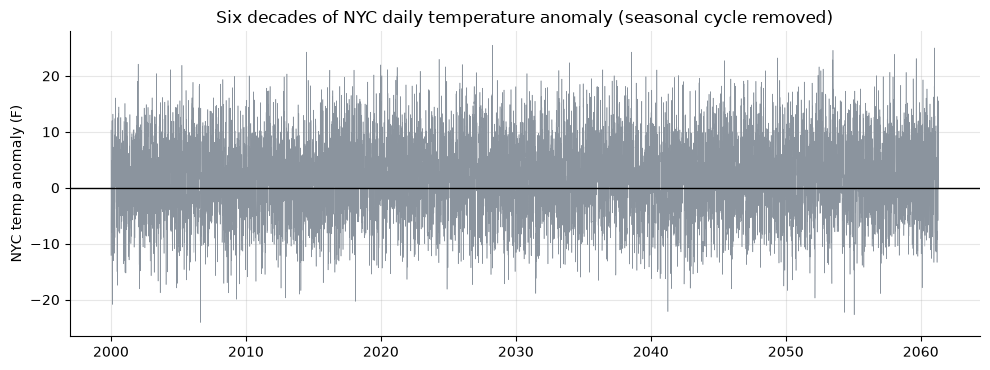

In [2]:
tbl = data.monthly_anomaly_table()
print('Monthly anomaly table:', len(tbl), 'rows,',
      tbl['year'].min(), '-', tbl['year'].max())
anom = TAPE['temp_anomaly_f']
print(f'Daily temperature anomaly: mean {anom.mean():+.2f} F, std {anom.std():.2f} F')
print(f'Coldest day: {anom.min():+.1f} F below normal | warmest: {anom.max():+.1f} F above')

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(TAPE.index, anom, lw=0.4, c=GREY)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('NYC temp anomaly (F)')
ax.set_title('Six decades of NYC daily temperature anomaly (seasonal cycle removed)')
plt.tight_layout(); plt.show()

**The cold vs warm sort -- the heart of the folklore.**

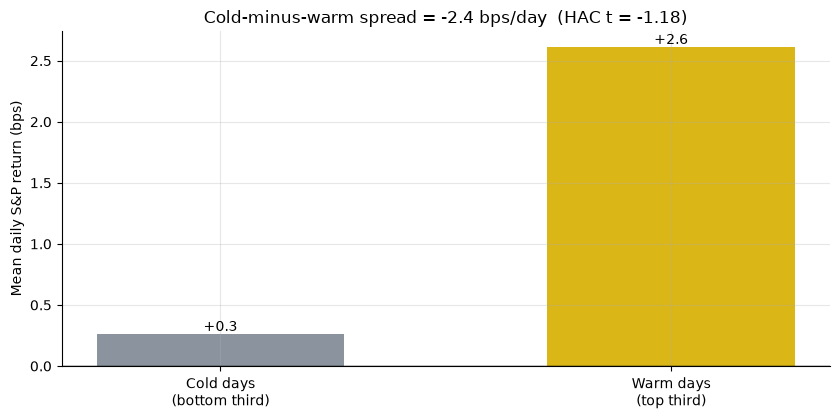

Cold days mean: +0.26 bps | Warm days mean: +2.61 bps
Spread: -2.35 bps/day, HAC t = -1.18
A |t| of ~1.2 is what you expect from pure chance. No signal.


In [3]:
cw = st.cold_warm_sort(TAPE)
if not HAVE_REAL:
    # quote frozen numbers alongside the synthetic stand-in for honesty
    cw_disp = dict(mean_cold_bps=R['mean_cold_bps'], mean_warm_bps=R['mean_warm_bps'],
                   spread_bps=R['spread_bps'], tstat=R['spread_tstat'])
else:
    cw_disp = cw

fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars = ax.bar(['Cold days\n(bottom third)', 'Warm days\n(top third)'],
              [cw_disp['mean_cold_bps'], cw_disp['mean_warm_bps']],
              color=[GREY, AMBER], width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean daily S&P return (bps)')
ax.set_title(f"Cold-minus-warm spread = {cw_disp['spread_bps']:+.1f} bps/day  "
             f"(HAC t = {cw_disp['tstat']:+.2f})")
for b, v in zip(bars, [cw_disp['mean_cold_bps'], cw_disp['mean_warm_bps']]):
    ax.annotate(f'{v:+.1f}', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom' if v>=0 else 'top')
plt.tight_layout(); plt.show()
print(f"Cold days mean: {cw_disp['mean_cold_bps']:+.2f} bps | "
      f"Warm days mean: {cw_disp['mean_warm_bps']:+.2f} bps")
print(f"Spread: {cw_disp['spread_bps']:+.2f} bps/day, HAC t = {cw_disp['tstat']:+.2f}")
print('A |t| of ~1.2 is what you expect from pure chance. No signal.')

Cold days and warm days earn essentially the same thing. The cold-minus-warm spread is about **-2.3 bps/day** with a robust t-stat near **-1.2** -- exactly the kind of wobble you get from shuffling labels at random. And note the *sign*: the folklore says cold should be bad (negative), but here cold days are marginally *better* -- the noise points whichever way it likes.

> Two basis points a day sounds like something, until you remember the market moves ~100 bps on an ordinary day. This is a whisper inside a hurricane.

## 5 - The verdict

- **Signal -- None.** Cold-minus-warm spread **-2.3 bps/day**, HAC t = **-1.2**; regressing returns on the anomaly gives R-squared ~ **0**; permutation p = **0.23**. Nothing clears the |t| >= 2 bar.
- **Tradability -- Mirage.** A cold-long / warm-short overlay loses money after a 1 bp one-way cost (net Sharpe **-0.2**) and churns ~55% turnover -- you pay to harvest noise.
- **Busted.** The 'temperature on Wall Street' is a behavioural just-so story. The mood mechanism may be real at the level of one nervous trader, but it is far too small to survive contact with daily equity volatility.

## 6 - Could you actually trade it?

The honest implementation: each morning, read yesterday's anomaly (one full day of execution lag), go long the S&P if it was a cold day and short if it was warm. Then pay the spread every time you flip.

In [4]:
bt = st.backtest_overlay(TAPE, cost_bps=1.0, lag=1)
if not HAVE_REAL:
    bt = dict(gross_sharpe=R['gross_sharpe'], net_sharpe=R['net_sharpe'],
              net_ann_ret=R['net_ann_ret'], turnover=R['turnover'],
              net_tstat=R['net_tstat'])
print(f"Gross Sharpe:           {bt['gross_sharpe']:+.2f}")
print(f"Net Sharpe (1 bp cost): {bt['net_sharpe']:+.2f}")
print(f"Net annualised return:  {bt['net_ann_ret']:+.1%}")
print(f"Turnover (avg |dpos|):  {bt['turnover']:.1%} per day")
print(f"Net HAC t-stat:         {bt['net_tstat']:+.2f}")
print()
print('Even gross, the overlay does not earn. Costs make it strictly worse.')
print('There is no trade here -- only churn.')

Gross Sharpe:           -0.09
Net Sharpe (1 bp cost): -0.19
Net annualised return:  -2.5%
Turnover (avg |dpos|):  55.3% per day
Net HAC t-stat:         -1.53

Even gross, the overlay does not earn. Costs make it strictly worse.
There is no trade here -- only churn.


The overlay is a money-loser before costs and worse after. It flips position about every other day (high turnover because weather is noisy), so transaction costs grind it down. The only edge weather gives you is deciding whether to bring an umbrella.

## 7 - Going further

- **The positive control:** the companion notebook plants a real cold-day premium into a synthetic tape and shows the exact same machinery lights up (HAC t > 7). The real NYC tape has nothing like that -- so the null result is about the *market*, not a broken test.
- **Cousins in the same family:** seasonal-affective and calendar-mood studies (the [daylight-saving](../../) and seasonal-anomaly teardowns) share this structure: a plausible mood story, a microscopic effect, a giant noise floor.

*Think the thermometer really moves the tape? Fork this, swap in your own city, cloud cover, or humidity series, and show a cold-minus-warm spread with HAC |t| >= 2 out of sample. That's the bar -- and a single weather station in Central Park doesn't clear it.*